In [1]:
# One-time environment setup (Jupyter-friendly)
# - pins NumPy/pandas/sklearn to avoid binary mismatch
# - installs small CPU-only PyTorch wheels (works without GPU)
# - you can switch to CUDA later if you want

%pip uninstall -y pyarrow
%pip install -U "numpy==1.26.4" "pandas==2.1.4" "scikit-learn==1.3.2" pillow matplotlib seaborn opencv-python tqdm "timm==1.0.9"

# PyTorch (CPU-only wheels: smaller, faster installs; OK for demo/training)
%pip install --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

print("✅ Setup done. Now go to: Kernel → Restart. Then continue with Cell 1.")

Note: you may need to restart the kernel to use updated packages.


  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
✅ Setup done. Now go to: Kernel → Restart. Then continue with Cell 1.


In [3]:
%pip install --index-url https://download.pytorch.org/whl/cpu torch torchvision torchaudio

Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [5]:
# === Block 0: Project setup & folders ===
from pathlib import Path
import random, shutil, os
from PIL import Image, UnidentifiedImageError

# ---- YOUR SOURCE DATA (original dataset that currently has only train/ and test/) ----
DATA_ROOT = r"C:\Users\itsra\Downloads\Dats\Pediatric Chest X-ray Pneumonia"  # keep as raw string

# ---- Project workspace (created in your current working dir) ----
from pathlib import Path
PROJECT   = Path.cwd() / "pediatric_pneumonia_xray"
SPLIT_DIR = PROJECT / "data_70_15_15_balancedtest"
MODEL_DIR = PROJECT / "models"
OUT_DIR   = PROJECT / "outputs"
for d in [PROJECT, SPLIT_DIR, MODEL_DIR, OUT_DIR]: d.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT)
print("Using source data:", DATA_ROOT)
print("Split will be created at:", SPLIT_DIR)


Project: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray
Using source data: C:\Users\itsra\Downloads\Dats\Pediatric Chest X-ray Pneumonia
Split will be created at: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\data_70_15_15_balancedtest


In [12]:
# CLEAN REBUILD: exactly 3688 per class, 70/15/15, no extra data, no undersampling in val/test,
#                augment only TRAIN/NORMAL to fill the gap. Original data left untouched.

from pathlib import Path
import random, shutil, os
from PIL import Image, ImageOps, UnidentifiedImageError
import numpy as np
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from tqdm import tqdm

# --- Config ---
DATA_ROOT = r"C:\Users\itsra\Downloads\Dats\Pediatric Chest X-ray Pneumonia"   # your original dataset (we read only from here)
PROJECT   = Path.cwd() / "pediatric_pneumonia_xray"
NEW_SPLIT_DIR = PROJECT / "data_FIXED_3688_each_70_15_15"  # new, clean split goes here
JPEG_QUALITY = 92
RND_SEED = 42

# EXACT per-class totals/splits
TOTAL_PER_CLASS = 3688
TRAIN_PER_CLASS = 2582
VAL_PER_CLASS   = 553
TEST_PER_CLASS  = 553
assert TRAIN_PER_CLASS + VAL_PER_CLASS + TEST_PER_CLASS == TOTAL_PER_CLASS

# Make sure write location is clean
if NEW_SPLIT_DIR.exists():
    print("Removing previous fixed split:", NEW_SPLIT_DIR)
    shutil.rmtree(NEW_SPLIT_DIR)
for sub in ["train","val","test"]:
    for cls in ["NORMAL","PNEUMONIA"]:
        (NEW_SPLIT_DIR/sub/cls).mkdir(parents=True, exist_ok=True)

random.seed(RND_SEED)

# ---------- helpers ----------
VALID_EXTS = {".jpg",".jpeg",".png",".bmp",".tif",".tiff"}
AUG_MARKERS = ("_aug_", "_flip", "_rot", "_noise", "_bright", "_contrast")

def is_augmented_name(p: Path) -> bool:
    n = p.name.lower()
    return any(m in n for m in AUG_MARKERS)

def list_originals(root_cls_dir: Path):
    """List only original files (exclude any augmented-looking names)."""
    files = []
    for p in root_cls_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in VALID_EXTS and not is_augmented_name(p):
            files.append(p)
    return files

def safe_copy_many(paths, dest_dir: Path):
    dest_dir.mkdir(parents=True, exist_ok=True)
    for sp in paths:
        dp = dest_dir / sp.name
        i = 1
        while dp.exists():
            dp = dest_dir / f"{sp.stem}_{i}{sp.suffix}"; i += 1
        shutil.copy2(sp, dp)

def augment_pil(img: Image.Image) -> Image.Image:
    """Fast, gentle X-ray augmentation (no vertical flips)."""
    img = img.convert("L")
    if random.random() < 0.5:
        img = ImageOps.mirror(img)  # left-right flip
    angle = random.uniform(-7, 7)
    img = img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
    tx = int(random.uniform(-0.02, 0.02) * img.width)
    ty = int(random.uniform(-0.02, 0.02) * img.height)
    scale = random.uniform(0.95, 1.05)
    shear = random.uniform(-3, 3)
    img = TF.affine(img, angle=0, translate=(tx,ty), scale=scale, shear=shear,
                    interpolation=InterpolationMode.BILINEAR, fill=0)
    img = TF.adjust_brightness(img, random.uniform(0.92, 1.08))
    img = TF.adjust_contrast(img,  random.uniform(0.92, 1.08))
    # keep noise optional & light for speed
    if random.random() < 0.25:
        arr = np.array(img).astype(np.float32)
        noise = np.random.normal(0, 2.5, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img = Image.fromarray(arr, mode="L")
    return img

def write_augmented(src: Path, out_dir: Path, idx: int):
    out = out_dir / f"{src.stem}_aug_{idx:05d}.jpg"
    j=1
    while out.exists():
        out = out_dir / f"{src.stem}_aug_{idx:05d}_{j}.jpg"; j+=1
    with Image.open(src) as im:
        aug = augment_pil(im)
    aug.save(out, format="JPEG", quality=JPEG_QUALITY, optimize=True)

def count_dir(d: Path):
    return sum(1 for p in d.iterdir() if p.is_file())

# ---------- Build clean pools from ORIGINAL dataset (train + test [+ val if present]) ----------
src_train = Path(DATA_ROOT) / "train"
src_test  = Path(DATA_ROOT) / "test"
src_val   = Path(DATA_ROOT) / "val"  # may or may not exist

def gather_class(cls_name):
    pool = []
    for root in [src_train, src_test, src_val]:
        if root.exists():
            cdir = root/cls_name
            if cdir.exists():
                pool += list_originals(cdir)
    random.shuffle(pool)
    return pool

pool_NORMAL    = gather_class("NORMAL")
pool_PNEUMONIA = gather_class("PNEUMONIA")
print(f"Original pools (excluding aug-like names): NORMAL={len(pool_NORMAL)}  PNEUMONIA={len(pool_PNEUMONIA)}")

# ---------- Choose EXACT totals per class ----------
# PNEUMONIA: we have enough originals → sample EXACTLY 3688
if len(pool_PNEUMONIA) < TOTAL_PER_CLASS:
    raise SystemExit(f"Not enough original PNEUMONIA to reach {TOTAL_PER_CLASS}: only {len(pool_PNEUMONIA)}")
pick_PNEU = random.sample(pool_PNEUMONIA, TOTAL_PER_CLASS)

# NORMAL: likely fewer than 3688 originals → take ALL originals, augment the rest
if len(pool_NORMAL) == 0:
    raise SystemExit("No original NORMAL images found.")
if len(pool_NORMAL) >= TOTAL_PER_CLASS:
    pick_NORM = random.sample(pool_NORMAL, TOTAL_PER_CLASS)
    need_aug = 0
else:
    pick_NORM = list(pool_NORMAL)  # all originals
    need_aug = TOTAL_PER_CLASS - len(pick_NORM)
print(f"Selected: NORMAL={len(pick_NORM)} (+{need_aug} aug)  PNEUMONIA={len(pick_PNEU)}")

# ---------- Split per class into train/val/test (val/test from ORIGINALS ONLY) ----------
def split_per_class(original_list, train_target, val_target, test_target):
    """Return (train_orig, val_orig, test_orig) — all from originals list."""
    random.shuffle(original_list)
    val = original_list[:val_target]
    test = original_list[val_target:val_target+test_target]
    train_orig = original_list[val_target+test_target : val_target+test_target+train_target]
    return train_orig, val, test

# PNEUMONIA: all from originals
pneu_train, pneu_val, pneu_test = split_per_class(pick_PNEU, TRAIN_PER_CLASS, VAL_PER_CLASS, TEST_PER_CLASS)

# NORMAL: use originals for val/test; remaining originals for train; then fill train with augmentation
# Ensure we have enough originals for val+test:
if len(pick_NORM) < (VAL_PER_CLASS + TEST_PER_CLASS):
    raise SystemExit(f"Not enough original NORMAL to cover val+test ({VAL_PER_CLASS+TEST_PER_CLASS}). Found {len(pick_NORM)}.")
# Make a copy to split
norm_for_split = list(pick_NORM)
random.shuffle(norm_for_split)
norm_val  = norm_for_split[:VAL_PER_CLASS]
norm_test = norm_for_split[VAL_PER_CLASS : VAL_PER_CLASS + TEST_PER_CLASS]
norm_train_orig = norm_for_split[VAL_PER_CLASS + TEST_PER_CLASS :]
# Top up NORMAL train with augmentations
norm_train_needed_aug = max(0, TRAIN_PER_CLASS - len(norm_train_orig))

print(f"Planned per-split counts:")
print(f"  NORMAL: train(orig)={len(norm_train_orig)} + aug={norm_train_needed_aug}  val={len(norm_val)}  test={len(norm_test)}")
print(f"  PNEUMONIA: train={len(pneu_train)}  val={len(pneu_val)}  test={len(pneu_test)}")

# ---------- Write files ----------
# Copy PNEUMONIA originals
safe_copy_many(pneu_train, NEW_SPLIT_DIR/"train"/"PNEUMONIA")
safe_copy_many(pneu_val,   NEW_SPLIT_DIR/"val"/"PNEUMONIA")
safe_copy_many(pneu_test,  NEW_SPLIT_DIR/"test"/"PNEUMONIA")

# Copy NORMAL originals (train part + val + test)
safe_copy_many(norm_train_orig, NEW_SPLIT_DIR/"train"/"NORMAL")
safe_copy_many(norm_val,        NEW_SPLIT_DIR/"val"/"NORMAL")
safe_copy_many(norm_test,       NEW_SPLIT_DIR/"test"/"NORMAL")

# Generate EXACT number of NORMAL augmentations for train
if norm_train_needed_aug > 0:
    print(f"Augmenting NORMAL for train by {norm_train_needed_aug} images…")
    candidates = list(pick_NORM)  # augment from original NORMAL pool
    if not candidates:
        raise SystemExit("No NORMAL originals to augment from.")
    idx = 0
    pbar = tqdm(total=norm_train_needed_aug, unit="img", desc="Augment NORMAL→train")
    while idx < norm_train_needed_aug:
        src = random.choice(candidates)
        try:
            write_augmented(src, NEW_SPLIT_DIR/"train"/"NORMAL", idx)
            idx += 1
            pbar.update(1)
        except (UnidentifiedImageError, OSError):
            continue
    pbar.close()

# ---------- Final sanity check & report ----------
def count_split(root):
    out = {}
    for split in ["train","val","test"]:
        out[split] = {}
        for cls in ["NORMAL","PNEUMONIA"]:
            out[split][cls] = count_dir(Path(root)/split/cls)
    return out

counts = count_split(NEW_SPLIT_DIR)
print("\nFinal counts in NEW split:")
for s in ["train","val","test"]:
    print(s, counts[s])

# Check exact totals
assert counts["train"]["NORMAL"]    == TRAIN_PER_CLASS
assert counts["train"]["PNEUMONIA"] == TRAIN_PER_CLASS
assert counts["val"]["NORMAL"]      == VAL_PER_CLASS
assert counts["val"]["PNEUMONIA"]   == VAL_PER_CLASS
assert counts["test"]["NORMAL"]     == TEST_PER_CLASS
assert counts["test"]["PNEUMONIA"]  == TEST_PER_CLASS
print("\n✅ EXACT 3688/3688 achieved with 70/15/15 per class. Val/Test are originals only. Train NORMAL augmented only.")

# IMPORTANT: point your downstream blocks to this split
SPLIT_DIR = NEW_SPLIT_DIR
print("\nUse this in later blocks → SPLIT_DIR =", SPLIT_DIR)


Removing previous fixed split: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\data_FIXED_3688_each_70_15_15
Original pools (excluding aug-like names): NORMAL=1583  PNEUMONIA=4273
Selected: NORMAL=1583 (+2105 aug)  PNEUMONIA=3688
Planned per-split counts:
  NORMAL: train(orig)=477 + aug=2105  val=553  test=553
  PNEUMONIA: train=2582  val=553  test=553
Augmenting NORMAL for train by 2105 images…



Augment NORMAL→train:   5%|██▊                                                     | 105/2105 [01:19<25:22,  1.31img/s]

Augment NORMAL→train:   0%|                                                          | 4/2105 [00:00<05:12,  6.71img/s]C:\Users\itsra\AppData\Local\Temp\ipykernel_13176\1406479693.py:81: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode="L")

Augment NORMAL→train: 100%|███████████████████████████████████████████████████████| 2105/2105 [11:10<00:00,  3.14img/s]



Final counts in NEW split:
train {'NORMAL': 2582, 'PNEUMONIA': 2582}
val {'NORMAL': 553, 'PNEUMONIA': 553}
test {'NORMAL': 553, 'PNEUMONIA': 553}

✅ EXACT 3688/3688 achieved with 70/15/15 per class. Val/Test are originals only. Train NORMAL augmented only.

Use this in later blocks → SPLIT_DIR = C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\data_FIXED_3688_each_70_15_15


In [14]:
# === Block 2: Imports, transforms, datasets, loaders ===
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt, seaborn as sns

# Repro & device
def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Transforms
IMG_SIZE = 224
MEAN = [0.485,0.456,0.406]
STD  = [0.229,0.224,0.225]

train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Datasets / Loaders
train_dir = SPLIT_DIR / "train"
val_dir   = SPLIT_DIR / "val"
test_dir  = SPLIT_DIR / "test"

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=eval_tfms)
test_ds  = datasets.ImageFolder(test_dir,  transform=eval_tfms)

class_to_idx = train_ds.class_to_idx            # {'NORMAL':0,'PNEUMONIA':1}
pos_label = class_to_idx["PNEUMONIA"]

BATCH_SIZE = 16
NUM_WORKERS = 0  # safer on Windows

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# pos_weight for BCEWithLogitsLoss
raw_labels = [1 if y==pos_label else 0 for _,y in datasets.ImageFolder(train_dir).imgs]
pos, neg = sum(raw_labels), len(raw_labels)-sum(raw_labels)
pos_weight = torch.tensor([neg/max(pos,1)], dtype=torch.float32, device=device)
print(f"Train: N={len(raw_labels)}  Pos={pos}  Neg={neg}  pos_weight={pos_weight.item():.3f}")


Device: cpu
Train: N=5164  Pos=2582  Neg=2582  pos_weight=1.000


In [20]:
# === Block 3: Model (DenseNet121), loss, optimizer, scheduler ===
from torchvision import models
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

def build_densenet121(dropout=0.5, pretrained=True):
    m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
    in_f = m.classifier.in_features
    m.classifier = nn.Sequential(nn.Dropout(dropout, inplace=True), nn.Linear(in_f, 1))
    return m

DROPOUT = 0.5
model = build_densenet121(dropout=DROPOUT, pretrained=True).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)  # verbose deprecated



Epoch 1/10


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [03:30<00:00,  3.01s/it]


Train: loss 0.1530 acc 0.9371 || Val: loss 0.1266 acc 0.9476 AUC 0.9923
✔ Saved: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\models\best_model.pt

Epoch 2/10


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [03:28<00:00,  2.98s/it]


Train: loss 0.0928 acc 0.9657 || Val: loss 0.1592 acc 0.9494 AUC 0.9884
✔ Saved: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\models\best_model.pt

Epoch 3/10


...

Train: loss 0.0338 acc 0.9893 || Val: loss 0.0798 acc 0.9711 AUC 0.9968
✔ Saved: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\models\best_model.pt

Epoch 9/10


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [03:12<00:00,  2.75s/it]


Train: loss 0.0225 acc 0.9936 || Val: loss 0.0853 acc 0.9702 AUC 0.9963

Epoch 10/10


100%|██████████████████████████████████████████████████████████████████████████████████| 70/70 [03:30<00:00,  3.01s/it]


Train: loss 0.0222 acc 0.9926 || Val: loss 0.1159 acc 0.9693 AUC 0.9977


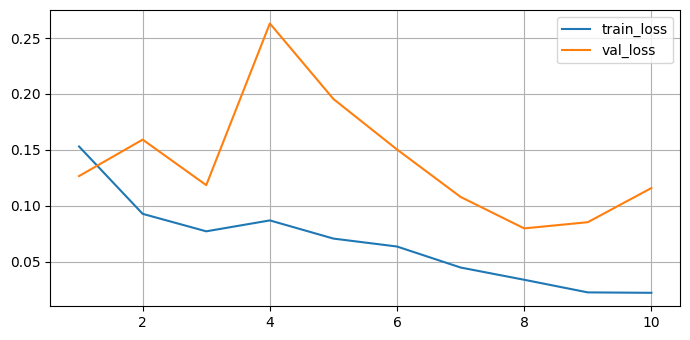

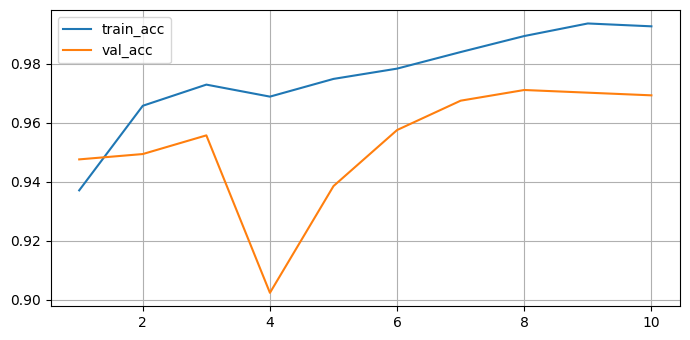

In [22]:
# === Block 4: Training (10 epochs), monitor val, save best by val accuracy ===
def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    losses, correct, total = [], 0, 0
    all_probs, all_trues = [], []
    for x, y_idx in tqdm(loader, disable=False):
        y = (y_idx == pos_label).float().unsqueeze(1).to(device)
        x = x.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
        probs = torch.sigmoid(logits).detach()
        preds = (probs >= 0.5).float()  # only for running accuracy (thresholded at 0.5)
        correct += (preds == y).sum().item()
        total += y.size(0)
        losses.append(loss.item())
        all_probs.append(probs.cpu().numpy()); all_trues.append(y.cpu().numpy())
    acc = correct/total
    y_true = np.vstack(all_trues).ravel()
    y_prob = np.vstack(all_probs).ravel()
    return float(np.mean(losses)), acc, y_true, y_prob

EPOCHS = 10
best_val_acc, history = -1, []

for ep in range(1, EPOCHS+1):
    print(f"\nEpoch {ep}/{EPOCHS}")
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, y_true_val, y_prob_val = run_epoch(val_loader, train=False)
    try: val_auc = roc_auc_score(y_true_val, y_prob_val)
    except: val_auc = float("nan")

    scheduler.step(val_loss)
    history.append(dict(epoch=ep, train_loss=tr_loss, train_acc=tr_acc,
                        val_loss=val_loss, val_acc=val_acc, val_auc=val_auc))
    print(f"Train: loss {tr_loss:.4f} acc {tr_acc:.4f} || Val: loss {val_loss:.4f} acc {val_acc:.4f} AUC {val_auc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_name": "densenet121",
            "state_dict": model.state_dict(),
            "img_size": IMG_SIZE,
            "mean": MEAN,
            "std": STD,
            "class_to_idx": class_to_idx,
            "dropout": DROPOUT
        }, MODEL_DIR / "best_model.pt")
        print("✔ Saved:", MODEL_DIR / "best_model.pt")

# quick curves
import pandas as pd
hist = pd.DataFrame(history)
plt.figure(figsize=(7,3.5)); plt.plot(hist.epoch, hist.train_loss, label="train_loss"); plt.plot(hist.epoch, hist.val_loss, label="val_loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
plt.figure(figsize=(7,3.5)); plt.plot(hist.epoch, hist.train_acc, label="train_acc"); plt.plot(hist.epoch, hist.val_acc, label="val_acc")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


C:\Users\itsra\AppData\Local\Temp\ipykernel_13176\2983899469.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location=

Tuned threshold: 0.522
AUC: 0.9982
@0.50 → Acc=0.979  Sens=0.987  Spec=0.971
@best → Acc=0.980  Sens=0.987  Spec=0.973
Saved: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\outputs\test_metrics.json


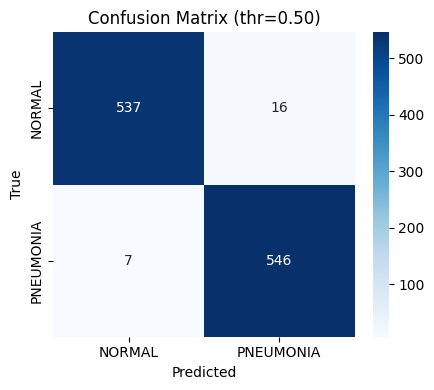

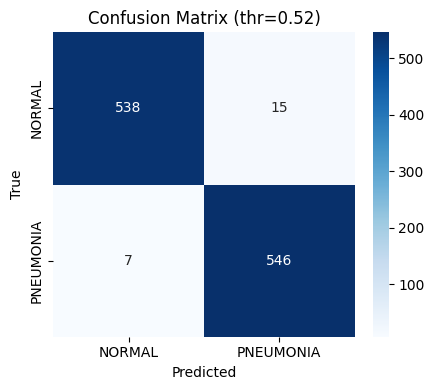

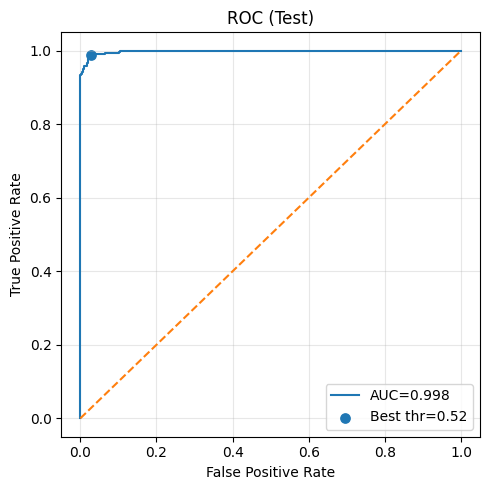

Saved ROC: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\outputs\roc_curve.png


In [24]:
# === Block 5: Evaluation on TEST (Accuracy, Sensitivity, Specificity, AUC) ===
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score

# load best model
ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location=device)
model_eval = build_densenet121(dropout=ckpt.get("dropout", 0.5), pretrained=False).to(device)
model_eval.load_state_dict(ckpt["state_dict"]); model_eval.eval()

IMG_SIZE = ckpt["img_size"]; MEAN = ckpt["mean"]; STD = ckpt["std"]
class_to_idx = ckpt["class_to_idx"]; pos_label = class_to_idx["PNEUMONIA"]

test_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_ds = datasets.ImageFolder(test_dir, transform=test_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# inference
probs_all, trues_all = [], []
with torch.no_grad():
    for x, y_idx in tqdm(test_loader, disable=False):
        y_true = (y_idx == pos_label).numpy().ravel()
        x = x.to(device)
        probs = torch.sigmoid(model_eval(x)).cpu().numpy().ravel()
        probs_all.append(probs); trues_all.append(y_true)

y_true = np.concatenate(trues_all); y_prob = np.concatenate(probs_all)

# ROC & AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)
youden = tpr - fpr
best_idx = int(np.argmax(youden))
best_thr = float(thresholds[best_idx])

def metrics_at(thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = accuracy_score(y_true, y_pred)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    return dict(threshold=float(thr), acc=float(acc), sens=float(sens), spec=float(spec),
                tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

m05   = metrics_at(0.50)
mbest = metrics_at(best_thr)

print(f"Tuned threshold: {best_thr:.3f}")
print(f"AUC: {auc:.4f}")
print(f"@0.50 → Acc={m05['acc']:.3f}  Sens={m05['sens']:.3f}  Spec={m05['spec']:.3f}")
print(f"@best → Acc={mbest['acc']:.3f}  Sens={mbest['sens']:.3f}  Spec={mbest['spec']:.3f}")

# save JSON
import json
summary = {
    "AUC": float(auc),
    "best_threshold": float(best_thr),
    "metrics_at_0.50": m05,
    "metrics_at_best": mbest,
}
with open(OUT_DIR/"test_metrics.json","w") as f: json.dump(summary, f, indent=2)
print("Saved:", (OUT_DIR/"test_metrics.json").resolve())

# Confusion matrices
plt.figure(figsize=(4.5,4))
cm = confusion_matrix(y_true, (y_prob>=0.50).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL","PNEUMONIA"], yticklabels=["NORMAL","PNEUMONIA"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (thr=0.50)")
plt.tight_layout(); plt.savefig(OUT_DIR/"cm_0-50.png", dpi=150); plt.show()

plt.figure(figsize=(4.5,4))
cm = confusion_matrix(y_true, (y_prob>=best_thr).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL","PNEUMONIA"], yticklabels=["NORMAL","PNEUMONIA"])
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix (thr={best_thr:.2f})")
plt.tight_layout(); plt.savefig(OUT_DIR/"cm_tuned.png", dpi=150); plt.show()

# ROC
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.scatter(fpr[best_idx], tpr[best_idx], s=45, label=f"Best thr={best_thr:.2f}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC (Test)"); plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR/"roc_curve.png", dpi=150); plt.show()
print("Saved ROC:", (OUT_DIR/"roc_curve.png").resolve())


In [26]:
# === Block 6: Grad-CAM on correct/misclassified test images ===
import cv2, numpy as np
from PIL import Image
from torchvision import transforms

GC_DIR = OUT_DIR / "gradcam"; GC_DIR.mkdir(parents=True, exist_ok=True)

# reuse model_eval from Block 5
def get_module_by_name(model, name):
    m = model
    for part in name.split("."):
        m = getattr(m, part) if not part.isdigit() else m[int(part)]
    return m

TARGET_LAYER = "features.denseblock4"  # good for DenseNet121

def gradcam_overlay(model, target_layer_name, pil_img):
    x = test_tfms(pil_img).unsqueeze(0).to(device)
    acts, grads = {}, {}
    layer = get_module_by_name(model, target_layer_name)

    def fwd(m, i, o): acts["v"] = o.detach()
    def bwd(m, gi, go): grads["v"] = go[0].detach()
    h1 = layer.register_forward_hook(fwd)
    h2 = layer.register_full_backward_hook(bwd)

    logits = model(x)
    prob = torch.sigmoid(logits).item()
    model.zero_grad(); logits[:,0].backward(retain_graph=True)

    A, G = acts["v"], grads["v"]
    w = G.mean(dim=(2,3), keepdim=True)
    cam = torch.relu((w*A).sum(dim=1, keepdim=True)).squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() + 1e-6)

    base = np.array(pil_img.convert("RGB"))
    cam_res = cv2.resize(cam, (base.shape[1], base.shape[0]))
    heat = cv2.applyColorMap(np.uint8(255*cam_res), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(base, 0.5, heat, 0.5, 0)
    h1.remove(); h2.remove()
    return overlay[..., ::-1], prob  # RGB

# Run predictions to pick examples
paths = [p for (p,_) in test_ds.samples]
true_idx = np.array([y for (_,y) in test_ds.samples])
y_true_bin = (true_idx == pos_label).astype(int)

with torch.no_grad():
    loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    probs_list = []
    for x,_ in loader:
        x = x.to(device)
        probs_list.append(torch.sigmoid(model_eval(x)).cpu().numpy().ravel())
y_prob = np.concatenate(probs_list)
y_pred = (y_prob >= summary.get("best_threshold", 0.5) if 'summary' in globals() else (y_prob >= 0.5)).astype(int)

# Select examples
import itertools
idx_correct_pneu = np.where((y_true_bin==1)&(y_pred==1))[0][:3]
idx_correct_norm = np.where((y_true_bin==0)&(y_pred==0))[0][:3]
idx_misclassified = np.where(y_true_bin!=y_pred)[0][:3]

def save_cam_for(indices, tag):
    for i in indices:
        p = paths[i]
        img = Image.open(p).convert("RGB")
        overlay, prob = gradcam_overlay(model_eval, TARGET_LAYER, img)
        out = GC_DIR / f"{tag}_{Path(p).stem}_p{prob:.2f}.png"
        Image.fromarray(overlay).save(out)

save_cam_for(idx_correct_pneu, "correct_pneumonia")
save_cam_for(idx_correct_norm, "correct_normal")
save_cam_for(idx_misclassified, "misclassified")

print("Grad-CAM saved to:", GC_DIR.resolve())


Grad-CAM saved to: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\outputs\gradcam


In [30]:
# Add this to your Jupyter Notebook and run it
torch.save(model.state_dict(), 'pneumonia_densenet_model.pth')
print("Model saved successfully as pneumonia_densenet_model.pth")

Model saved successfully as pneumonia_densenet_model.pth


In [28]:
# === Block 7: Predict on a single image OR a whole folder you provide ===
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd
from tqdm import tqdm

# ---- Provide your path here (file OR directory) ----
INPUT_PATH = r"C:\Users\itsra\Downloads\chest_xray\val\PNEUMONIA"  # e.g. r"...\img.jpg" or r"...\some\folder"
# ----------------------------------------------------

thr = summary["best_threshold"] if 'summary' in globals() else 0.50  # use tuned threshold if available
print("Using threshold:", round(thr,3))

def predict_one(pil_img):
    x = test_tfms(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model_eval(x)).item()
    lab = "PNEUMONIA" if prob >= thr else "NORMAL"
    return prob, lab

p = Path(INPUT_PATH)
assert p.exists(), f"Path not found: {INPUT_PATH}"

valid_exts = {".jpg",".jpeg",".png",".bmp",".tif",".tiff"}
if p.is_file():
    img = Image.open(p).convert("RGB")
    prob, lab = predict_one(img)
    print(f"Path: {p}\nPneumonia probability: {prob:.3f}\nPrediction: {lab}")
else:
    files = [q for q in p.rglob("*") if q.is_file() and q.suffix.lower() in valid_exts]
    files.sort(key=lambda x: str(x).lower())
    print(f"Found {len(files)} images in folder.")
    rows=[]
    with torch.no_grad():
        batch, paths = [], []
        for f in tqdm(files, unit="img", desc="Scoring"):
            try:
                img = Image.open(f).convert("RGB")
            except (UnidentifiedImageError, OSError):
                continue
            x = test_tfms(img)
            batch.append(x); paths.append(str(f))
            if len(batch)==32:
                X = torch.stack(batch).to(device)
                pr = torch.sigmoid(model_eval(X)).cpu().numpy().ravel()
                for path_i, prob_i in zip(paths, pr):
                    rows.append({"path": path_i,
                                 "prob_pneumonia": float(prob_i),
                                 "prediction": "PNEUMONIA" if prob_i>=thr else "NORMAL"})
                batch, paths = [], []
        if batch:
            X = torch.stack(batch).to(device)
            pr = torch.sigmoid(model_eval(X)).cpu().numpy().ravel()
            for path_i, prob_i in zip(paths, pr):
                rows.append({"path": path_i,
                             "prob_pneumonia": float(prob_i),
                             "prediction": "PNEUMONIA" if prob_i>=thr else "NORMAL"})
    df = pd.DataFrame(rows).sort_values("prob_pneumonia", ascending=False).reset_index(drop=True)
    csv_path = OUT_DIR / f"predictions_{p.name}.csv"
    df.to_csv(csv_path, index=False)
    print("Saved predictions CSV →", csv_path.resolve())
    display(df.head(20))


Using threshold: 0.522


AssertionError: Path not found: C:\Users\itsra\Downloads\chest_xray\val\PNEUMONIA

In [23]:
import os, random, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, transforms, models
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from tqdm import tqdm

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
set_seed(42)

DATA_DIR  = r"C:\Users\itsra\Downloads\Pediatric Chest X-ray Pneumonia"
PROJECT   = Path.cwd() / "pediatric_pneumonia_xray"
OUT_DIR   = PROJECT / "outputs"
MODEL_DIR = PROJECT / "models"
for d in [PROJECT, OUT_DIR, MODEL_DIR]: d.mkdir(parents=True, exist_ok=True)

train_dir = Path(DATA_DIR) / "train"
val_dir   = Path(DATA_DIR) / "val"
test_dir  = Path(DATA_DIR) / "test"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [25]:
print("Splits exist:", train_dir.exists(), val_dir.exists(), test_dir.exists())
if not val_dir.exists():
    print("Creating val split (10%) from train...")
    for cls in ["NORMAL", "PNEUMONIA"]:
        (val_dir/cls).mkdir(parents=True, exist_ok=True)
        imgs = list((train_dir/cls).glob("*"))
        random.shuffle(imgs)
        n_val = max(1, int(0.1 * len(imgs)))
        for p in imgs[:n_val]:
            shutil.move(str(p), str(val_dir/cls/p.name))
    print("Done.")

# remove corrupted images if any
bad = []
for split in ["train","val","test"]:
    for cls in ["NORMAL","PNEUMONIA"]:
        for fp in (Path(DATA_DIR)/split/cls).glob("*"):
            try:
                with Image.open(fp) as im: _ = im.size, im.mode
            except (UnidentifiedImageError, OSError):
                bad.append(str(fp))
for p in bad:
    try: os.remove(p)
    except FileNotFoundError: pass
print("Corrupted removed:", len(bad))

def counts(root):
    rows=[]
    for s in ["train","val","test"]:
        for c in ["NORMAL","PNEUMONIA"]:
            rows.append((s,c,len(list((Path(root)/s/c).glob("*")))))
    return pd.DataFrame(rows, columns=["split","class","num_images"])
counts(DATA_DIR)

Splits exist: True False True
Creating val split (10%) from train...
Done.
Corrupted removed: 0


,split,class,num_images
0,train,NORMAL,1215
1,train,PNEUMONIA,3495
2,val,NORMAL,134
3,val,PNEUMONIA,388
4,test,NORMAL,234
5,test,PNEUMONIA,390


In [26]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
BATCH_SIZE = 16   # CPU-friendly
NUM_WORKERS = 0   # safer on Windows

train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir,   transform=eval_tfms)
test_ds  = datasets.ImageFolder(test_dir,  transform=eval_tfms)

class_to_idx = train_ds.class_to_idx           # {'NORMAL':0, 'PNEUMONIA':1}
idx_to_class = {v:k for k,v in class_to_idx.items()}
pos_label    = class_to_idx['PNEUMONIA']

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# imbalance weight
raw_labels = [1 if y==pos_label else 0 for _,y in datasets.ImageFolder(train_dir).imgs]
pos, neg = sum(raw_labels), len(raw_labels)-sum(raw_labels)
pos_weight = torch.tensor([neg / max(pos,1)], dtype=torch.float32).to(device)
print(f"Train N={len(raw_labels)} | Pos={pos} Neg={neg} | pos_weight={pos_weight.item():.3f}")

Train N=4710 | Pos=3495 Neg=1215 | pos_weight=0.348


In [27]:
def build_model(model_name="efficientnet_b0", dropout=0.5, pretrained=True):
    mname = model_name.lower()
    if mname == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT if pretrained else None)
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout, inplace=True), nn.Linear(in_f, 1))
        target_layer = "features.6"
    elif mname == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        in_f = m.classifier.in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout, inplace=True), nn.Linear(in_f, 1))
        target_layer = "features.denseblock4"
    else:
        raise ValueError("Use 'efficientnet_b0' or 'densenet121'")
    return m, target_layer

MODEL_NAME, DROPOUT = "efficientnet_b0", 0.5
model, TARGET_LAYER = build_model(MODEL_NAME, dropout=DROPOUT, pretrained=True)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)


Epoch 1/10


Train: loss 0.0883 acc 0.9291 || Val: loss 1.1567 acc 0.6250 AUC 0.9688
✔ Saved best_model.pt

Epoch 2/10


Train: loss 0.0481 acc 0.9630 || Val: loss 0.2877 acc 0.8125 AUC 1.0000
✔ Saved best_model.pt

Epoch 3/10


Train: loss 0.0346 acc 0.9730 || Val: loss 0.0304 acc 1.0000 AUC 1.0000
✔ Saved best_model.pt

Epoch 4/10


Train: loss 0.0320 acc 0.9751 || Val: loss 0.2869 acc 0.8125 AUC 1.0000

Epoch 5/10


...

Train: loss 0.0237 acc 0.9839 || Val: loss 0.0112 acc 1.0000 AUC 1.0000

Epoch 7/10


Train: loss 0.0192 acc 0.9847 || Val: loss 0.0185 acc 1.0000 AUC 1.0000

Epoch 8/10


Train: loss 0.0128 acc 0.9906 || Val: loss 0.2434 acc 0.8750 AUC 1.0000

Epoch 9/10


Train: loss 0.0182 acc 0.9870 || Val: loss 0.0298 acc 1.0000 AUC 1.0000

Epoch 10/10


Train: loss 0.0113 acc 0.9918 || Val: loss 0.0165 acc 1.0000 AUC 1.0000


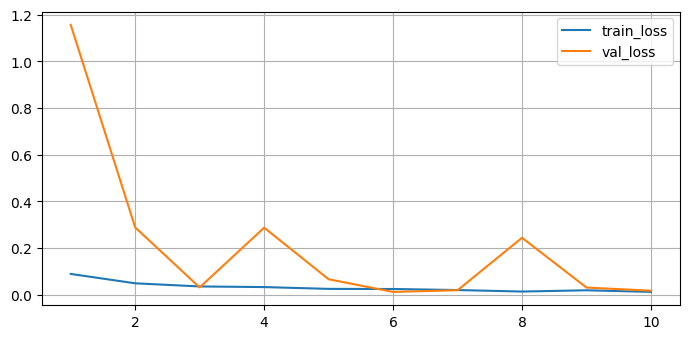

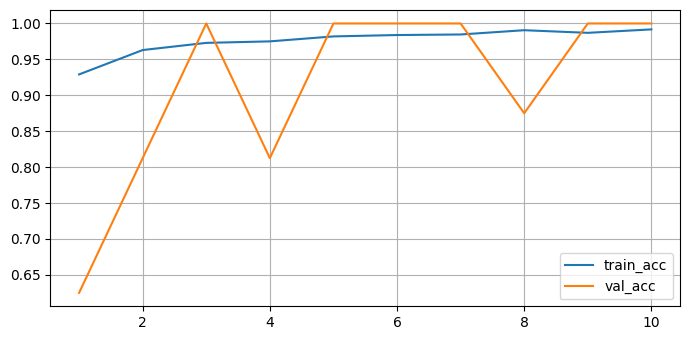

In [13]:
def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    losses, correct, total = [], 0, 0
    all_probs, all_trues = [], []
    for x, y_idx in tqdm(loader, leave=False):
        y = (y_idx == pos_label).float().unsqueeze(1).to(device)
        x = x.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                loss.backward()
                optimizer.step()
        probs = torch.sigmoid(logits).detach()
        preds = (probs >= 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)
        losses.append(loss.item())
        all_probs.append(probs.cpu().numpy()); all_trues.append(y.cpu().numpy())
    acc = correct/total
    y_true = np.vstack(all_trues).ravel()
    y_prob = np.vstack(all_probs).ravel()
    return float(np.mean(losses)), acc, y_true, y_prob

EPOCHS = 10
best_val_acc, history = -1, []

for ep in range(1, EPOCHS+1):
    print(f"\nEpoch {ep}/{EPOCHS}")
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, train=True)
    val_loss, val_acc, y_true_val, y_prob_val = run_epoch(val_loader, train=False)
    try: val_auc = roc_auc_score(y_true_val, y_prob_val)
    except: val_auc = float("nan")
    scheduler.step(val_loss)
    history.append(dict(epoch=ep, train_loss=tr_loss, train_acc=tr_acc,
                        val_loss=val_loss, val_acc=val_acc, val_auc=val_auc))
    print(f"Train: loss {tr_loss:.4f} acc {tr_acc:.4f} || Val: loss {val_loss:.4f} acc {val_acc:.4f} AUC {val_auc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_name": MODEL_NAME,
            "state_dict": model.state_dict(),
            "target_layer": TARGET_LAYER,
            "img_size": IMG_SIZE,
            "mean": IMAGENET_MEAN,
            "std": IMAGENET_STD,
            "class_to_idx": class_to_idx
        }, MODEL_DIR / "best_model.pt")
        print("✔ Saved best_model.pt")

# (optional) quick curves
hist = pd.DataFrame(history)
plt.figure(figsize=(7,3.5)); plt.plot(hist.epoch, hist.train_loss, label="train_loss"); plt.plot(hist.epoch, hist.val_loss, label="val_loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,3.5)); plt.plot(hist.epoch, hist.train_acc, label="train_acc"); plt.plot(hist.epoch, hist.val_acc, label="val_acc")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

C:\Users\itsra\AppData\Local\Temp\ipykernel_25072\463072099.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location=d


AUC: 0.9745
thr=0.50  → Acc=0.920  Sens/Recall=0.987  Spec=0.808  (tn=189 fp=45 fn=5 tp=385)
thr=0.899 → Acc=0.913  Sens/Recall=0.923  Spec=0.897  (tn=210 fp=24 fn=30 tp=360)
Saved → C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\outputs\test_metrics.json


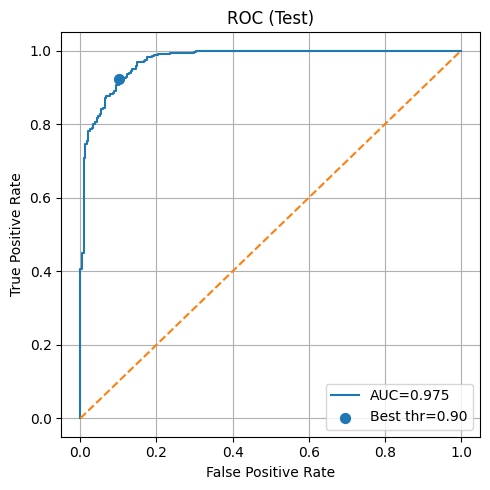

Saved ROC → C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\outputs\roc_curve.png


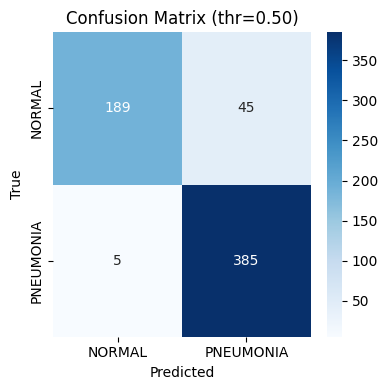

Saved: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\outputs\cm_0-50.png


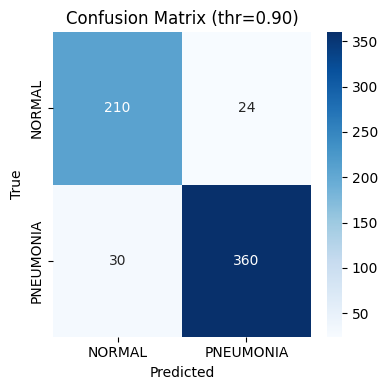

Saved: C:\Users\itsra\Chest X-Ray\pediatric_pneumonia_xray\outputs\cm_0-9.png


In [15]:
# Load best model
ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location=device)
m_eval, _ = build_model(ckpt["model_name"], dropout=DROPOUT, pretrained=False)
m_eval.load_state_dict(ckpt["state_dict"])
m_eval = m_eval.to(device).eval()

IMG_SIZE = ckpt["img_size"]; MEAN = ckpt["mean"]; STD = ckpt["std"]
class_to_idx = ckpt["class_to_idx"]; pos_label = class_to_idx["PNEUMONIA"]

# Test loader with same eval transforms
eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_ds = datasets.ImageFolder(test_dir, transform=eval_tfms)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Inference
probs_all, trues_all = [], []
with torch.no_grad():
    for x, y_idx in tqdm(test_loader, leave=False):
        y_true = (y_idx == pos_label).numpy().ravel()
        x = x.to(device)
        probs = torch.sigmoid(m_eval(x)).cpu().numpy().ravel()
        probs_all.append(probs); trues_all.append(y_true)

y_true = np.concatenate(trues_all)
y_prob = np.concatenate(probs_all)

# ROC + AUC
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

# Tuned threshold: maximize Youden's J = TPR - FPR
youden = tpr - fpr
best_idx = int(np.argmax(youden))
best_thr = float(thresholds[best_idx])

def metrics_at(thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = (tp+tn)/(tp+tn+fp+fn)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0.0   # recall
    spec = tn/(tn+fp) if (tn+fp)>0 else 0.0
    return dict(acc=acc, sens=sens, spec=spec, tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))

m05   = metrics_at(0.50)
mbest = metrics_at(best_thr)

print(f"\nAUC: {auc:.4f}")
print(f"thr=0.50  → Acc={m05['acc']:.3f}  Sens/Recall={m05['sens']:.3f}  Spec={m05['spec']:.3f}  (tn={m05['tn']} fp={m05['fp']} fn={m05['fn']} tp={m05['tp']})")
print(f"thr={best_thr:.3f} → Acc={mbest['acc']:.3f}  Sens/Recall={mbest['sens']:.3f}  Spec={mbest['spec']:.3f}  (tn={mbest['tn']} fp={mbest['fp']} fn={mbest['fn']} tp={mbest['tp']})")

# Save JSON summary
OUT_DIR.mkdir(parents=True, exist_ok=True)
summary = {
    "AUC": float(auc),
    "best_threshold": float(best_thr),
    "threshold_0.5": {"threshold": 0.50, **{k: float(v) if isinstance(v,(int,float)) else v for k,v in m05.items()}},
    "threshold_best": {"threshold": float(best_thr), **{k: float(v) if isinstance(v,(int,float)) else v for k,v in mbest.items()}},
}
with open(OUT_DIR/"test_metrics.json","w") as f: json.dump(summary, f, indent=2)
print("Saved →", (OUT_DIR/"test_metrics.json").resolve())

# ROC curve
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.scatter(fpr[best_idx], tpr[best_idx], s=50, label=f"Best thr={best_thr:.2f}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC (Test)"); plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(OUT_DIR/"roc_curve.png", dpi=150); plt.show()
print("Saved ROC →", (OUT_DIR/"roc_curve.png").resolve())

# Confusion matrices
def save_cm(thr, name):
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["NORMAL","PNEUMONIA"], yticklabels=["NORMAL","PNEUMONIA"])
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix (thr={thr:.2f})")
    plt.tight_layout()
    p = OUT_DIR/name
    plt.savefig(p, dpi=150); plt.show()
    print("Saved:", p.resolve())

save_cm(0.50, "cm_0-50.png")
save_cm(best_thr, f"cm_{str(round(best_thr,2)).replace('.','-')}.png")

In [21]:
# --- Single-image prediction (paste into a new cell) ---
import json
from pathlib import Path
from PIL import Image
import torch, torch.nn as nn
import torchvision.transforms as T
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = Path("pediatric_pneumonia_xray/models/best_model.pt")

# Load checkpoint and rebuild the trained model
ckpt = torch.load(CKPT_PATH, map_location=device)
def build_from_ckpt(ckpt, dropout=0.5):
    if ckpt["model_name"] == "efficientnet_b0":
        m = models.efficientnet_b0(weights=None)
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout, inplace=True), nn.Linear(in_f, 1))
    else:  # densenet121 path
        m = models.densenet121(weights=None)
        in_f = m.classifier.in_features
        m.classifier = nn.Sequential(nn.Dropout(dropout, inplace=True), nn.Linear(in_f, 1))
    m.load_state_dict(ckpt["state_dict"])
    return m.to(device).eval()

model = build_from_ckpt(ckpt, dropout=0.5)
IMG_SIZE, MEAN, STD = ckpt["img_size"], ckpt["mean"], ckpt["std"]

transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# Use tuned threshold if available, else 0.50
thr = 0.50
try:
    with open("pediatric_pneumonia_xray/outputs/test_metrics.json") as f:
        thr = float(json.load(f).get("best_threshold", 0.50))
except FileNotFoundError:
    pass

def predict_image(path, threshold=thr):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).item()  # probability of PNEUMONIA
    pred = "PNEUMONIA" if prob >= threshold else "NORMAL"
    print(f"Path: {path}")
    print(f"Pneumonia probability: {prob:.3f}  |  Threshold: {threshold:.2f}")
    print(f"Prediction: {pred}")

# === set your local path here (or uncomment input() to type it) ===
image_path = r"C:\Users\itsra\Downloads\chest_xray\val\NORMAL\NORMAL2-IM-1427-0001.jpeg"
predict_image(image_path)
# image_path = input('Enter image path: ').strip()
image_path = r"C:\Users\itsra\Downloads\chest_xray\download.jpeg"
predict_image(image_path)

C:\Users\itsra\AppData\Local\Temp\ipykernel_25072\3615657876.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


Path: C:\Users\itsra\Downloads\chest_xray\val\NORMAL\NORMAL2-IM-1427-0001.jpeg
Pneumonia probability: 0.012  |  Threshold: 0.90
Prediction: NORMAL
Path: C:\Users\itsra\Downloads\chest_xray\download.jpeg
Pneumonia probability: 0.414  |  Threshold: 0.90
Prediction: NORMAL
